# Experimento 16

## Línea de base modelo 1D (ResNet1D)

In [1]:
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d, signal_grad_cam_single1d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1781119292.997997    6212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781119293.028745    6212 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781119293.851796    6212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781119293.852102    6212 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '16-modelo_1d_baseline/final'
checkpoints_path = '16-modelo_1d_baseline/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/16-modelo_1d_baseline')
batch_size = 48 #El hardware a disposición no puede con más 
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        with_log = True,
        device = DEVICE,
        mode = "training",
        output = "waveform")

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        with_log = True,
        device = DEVICE,
        output = "waveform")
# Modelo
model1D = AudioResNetModel(dims=1, num_classes=NUM_CLASSES).get_model()
model1D.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model1D, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=epochs)                        
trainer.fit(resume=False)

Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/1544 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 1/10
  Train - Pérdida: 2.3624, Accuracy: 0.3563, F1-score: 0.2976
  Val   - Pérdida: 19.2646, Accuracy: 0.0650, F1-score: 0.0301


Batches entrenamiento:   0%|          | 0/1544 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.9869, Accuracy: 0.7341, F1-score: 0.7175
  Val   - Pérdida: 1.1344, Accuracy: 0.7126, F1-score: 0.6960


Batches entrenamiento:   0%|          | 0/1544 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.9498, Accuracy: 0.7421, F1-score: 0.7253
  Val   - Pérdida: 1.0359, Accuracy: 0.7179, F1-score: 0.6970


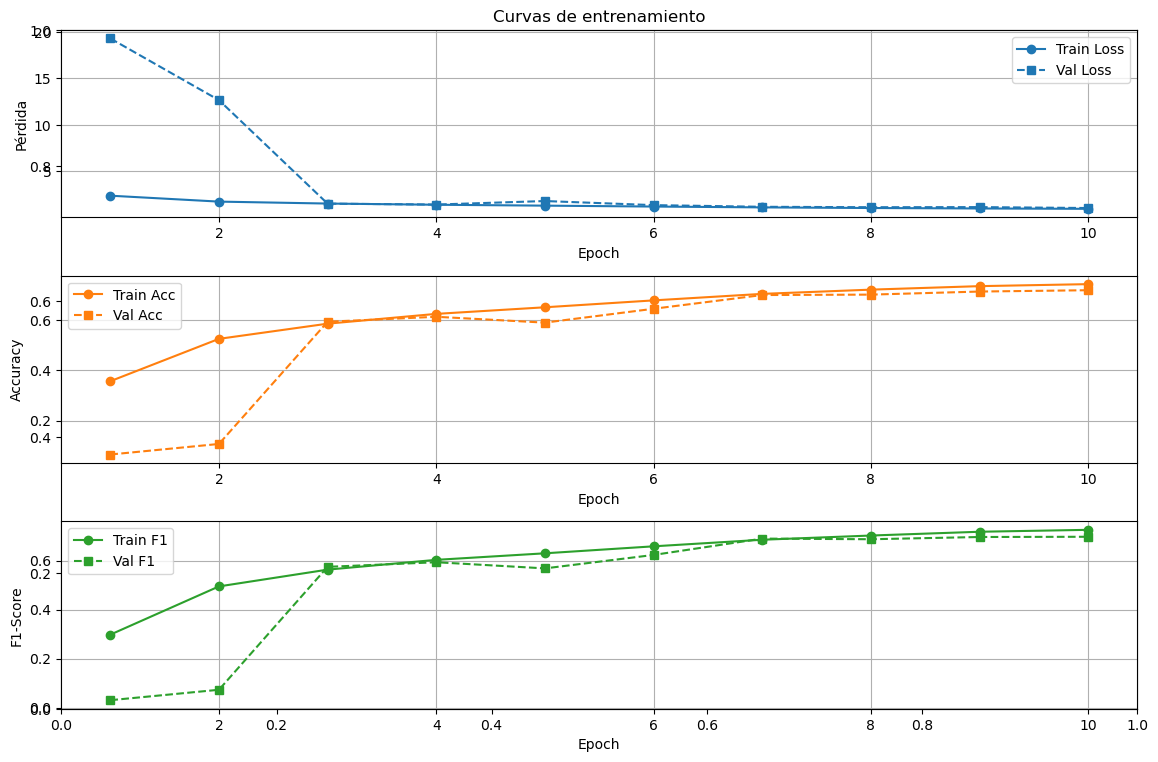

In [6]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=1, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

Las curvas evolucionan de manera muy adecuada, con poco margen entre ellas, lo que indica que en este caso no se produce un sobreajuste en el entrenamiento. El modelo aprende lenta y sostenidamente.

In [7]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/221 [00:00<?, ?it/s]

Pérdida: 1.3542046954345217 Accuracy: 0.6824796824796825 F1-Score: 0.6540771484023803


In [8]:
# Ratio entre f1 test y f1 en val
print("Ratio test/val F1:", f1/loaded_pt['history'].get('val_f1')[9])
print("Ratio test/val Accuracy:", accuracy/loaded_pt['history'].get('val_acc')[9])

Ratio test/val F1: 0.9383733444583843
Ratio test/val Accuracy: 0.9506384098986441


Se trata de un modelo aún por entrenar más en profundidad, ya que el entrenamiento no ha dado muestras de estancamiento alguno. La generalización al conjunto de test es buena, ya que el ratio entre las métricas de val y test es superior a 0.9. Sin embargo, el rendimiento del modelo es aún pobre y debe se entrenado más en profundidad. Esta aproximación requiere de más recursos computacionales que el entrenamiento en 2D anterior. Dado el punto del entrenamiento que se está estudiando, se considera que no merece la pena estudiar la matriz de confusión. Sí evaluaremos nuestras muestras de referencia con XAI para obtener una base de referencia al aplicar la pipeline que ha dado mejores resultados con el modelo 2D. 

In [9]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [10]:
## Generamos los CAMs
target_layers = ['basicblock_list.0.conv2.conv', 'basicblock_list.1.conv2.conv',
                 'basicblock_list.2.conv2.conv', 'basicblock_list.3.conv2.conv',
                 'basicblock_list.4.conv2.conv', 'basicblock_list.5.conv2.conv',
                 'basicblock_list.6.conv2.conv', 'basicblock_list.7.conv2.conv']

explainer = "Grad-CAM"

In [11]:
%%capture
signal_grad_cam_single1d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

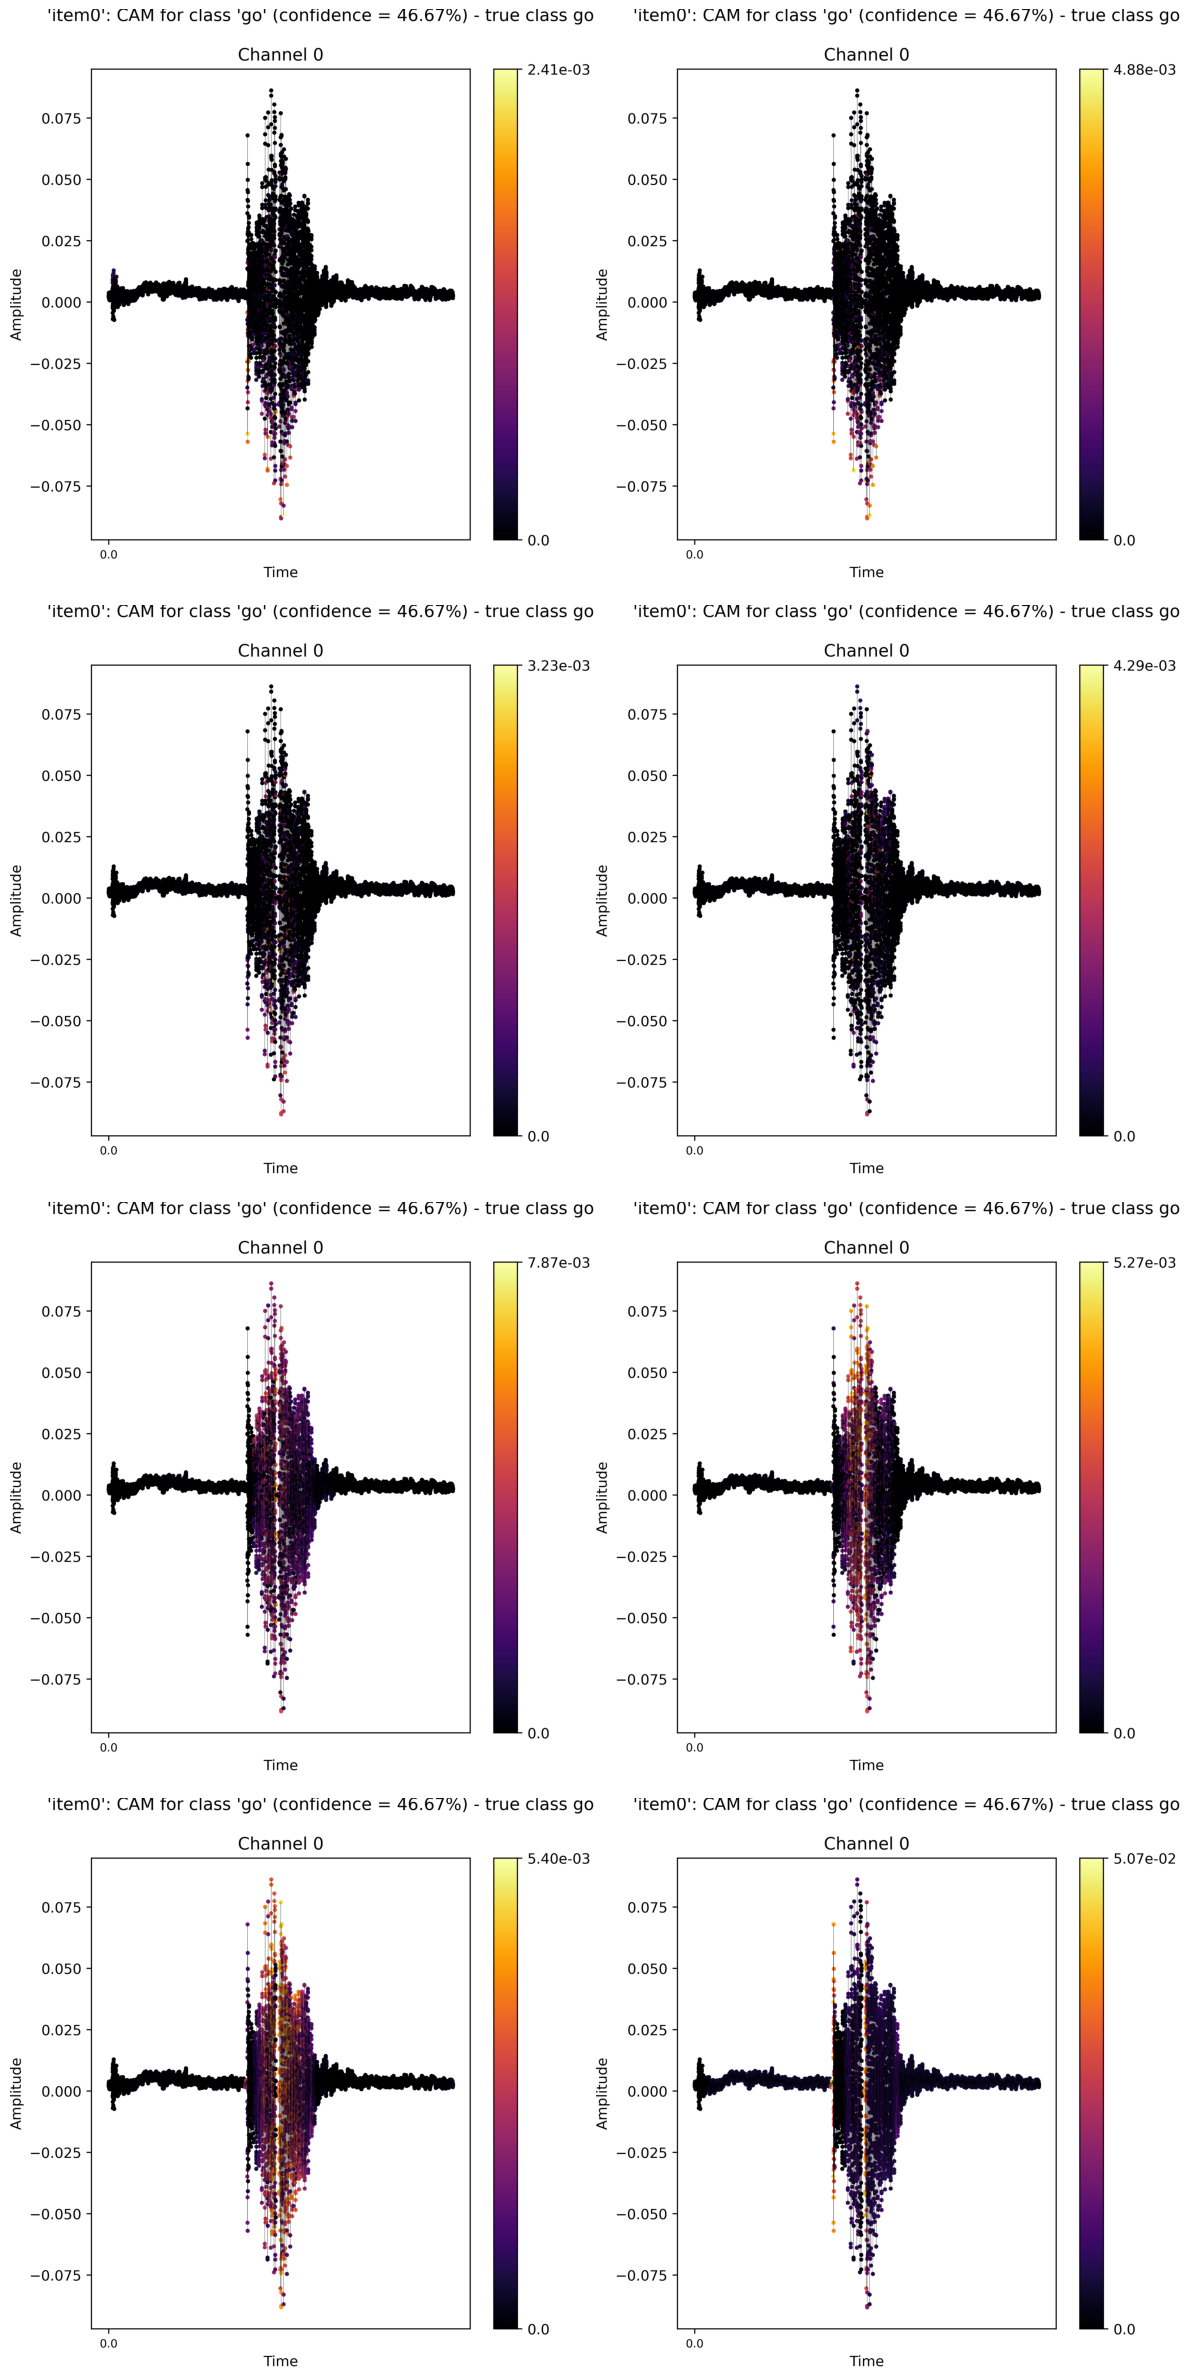

In [13]:
## Visualizamos
images_to_show = sorted(Path(f"{xai_path}/CAMs/single_channel/item0/").glob("*11.png"))
show_image_grid(images_to_show, rows=4, cols =2, figsize=(12,24))

Vamos a observar con más resolución la última capa:

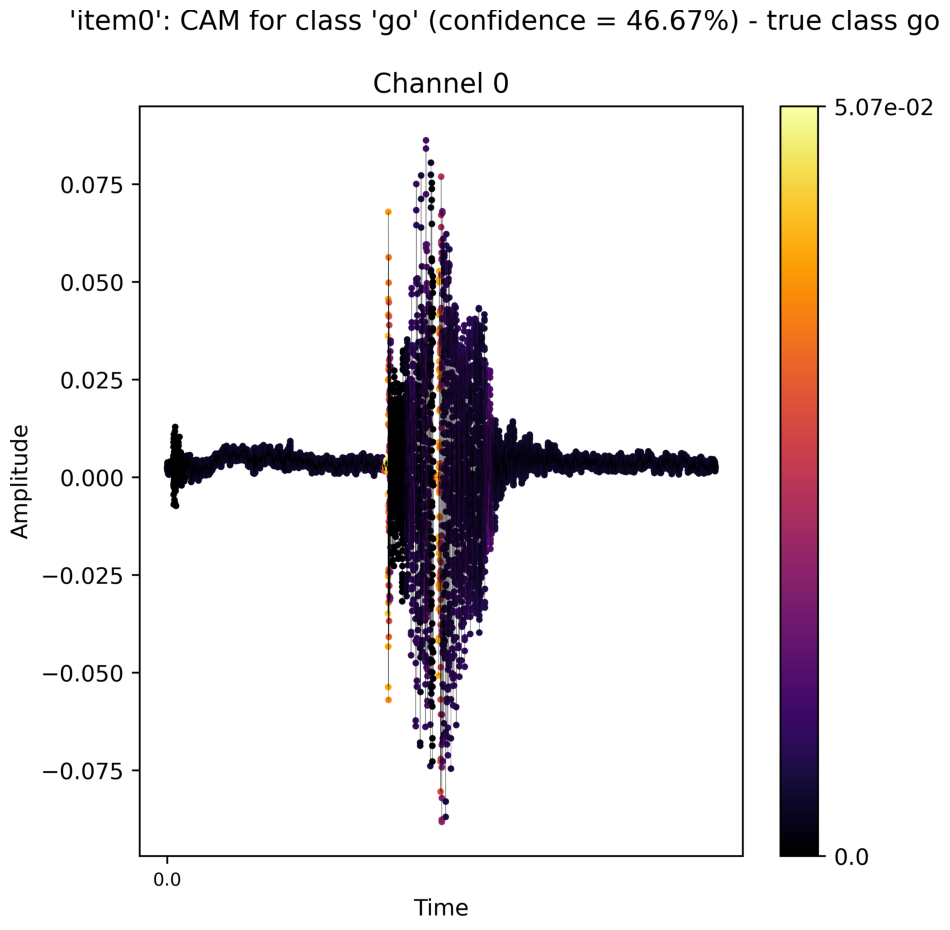

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(Path(f"{xai_path}/CAMs/single_channel/item0/channel_graphs_Grad-CAM_basicblock_list_7_conv2_conv_class11.png"))
plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis("off")
plt.show()

Vemos que la mayor atención del modelo se centra en el principio de la consonante y en el principio de la vocal después de la plosión glotal. Da la impresión de que los feature maps de los filtros aún no contienen patrones más concluyentes con respecto a la activación de esta clase.